In [1]:
# Importing all necessary libraries here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score,roc_curve, auc, precision_recall_curve, f1_score
from sklearn.preprocessing import StandardScaler

In [2]:
#reading in the data; adjust as needed

df = pd.read_csv(r'C:\Users\User\Downloads\startup data.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                923 non-null    int64  
 1   state_code                923 non-null    object 
 2   latitude                  923 non-null    float64
 3   longitude                 923 non-null    float64
 4   zip_code                  923 non-null    object 
 5   id                        923 non-null    object 
 6   city                      923 non-null    object 
 7   Unnamed: 6                430 non-null    object 
 8   name                      923 non-null    object 
 9   labels                    923 non-null    int64  
 10  founded_at                923 non-null    object 
 11  closed_at                 335 non-null    object 
 12  first_funding_at          923 non-null    object 
 13  last_funding_at           923 non-null    object 
 14  age_first_

In [3]:
# This stndardizes all non 0/1 columns in the dataset

numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
non_binary_columns = [col for col in numerical_columns if df[col].nunique() > 2]
scaler = StandardScaler()
df[non_binary_columns] = scaler.fit_transform(df[non_binary_columns])
print(df[non_binary_columns].head)

<bound method NDFrame.head of      Unnamed: 0  latitude  longitude  age_first_funding_year  \
0      1.297828  1.027268   1.451271                0.005448   
1     -1.104657 -0.341900  -0.823630                1.151960   
2      1.285831 -1.501922  -0.610018               -0.479349   
3      0.497000 -0.320134  -0.827040                0.357050   
4      1.288830 -0.197397  -0.843535               -0.891013   
..          ...       ...        ...                     ...   
918   -0.660752 -0.207743  -0.841624               -0.684643   
919    0.446011  1.066294   1.445070                1.999320   
920   -0.045884 -0.296615  -0.825515                2.495038   
921    0.050095 -0.256911  -0.837688               -0.588552   
922   -0.330823 -0.302359  -0.823297                0.352666   

     age_last_funding_year  age_first_milestone_year  age_last_milestone_year  \
0                -0.313102                  0.542211                 0.607372   
1                 2.044918             

In [4]:
# encoding the dependent variable

df['status'] = df.status.map({'acquired':1, 'closed':0})
df['status'].astype(int)

0      1
1      1
2      1
3      1
4      0
      ..
918    1
919    0
920    0
921    1
922    1
Name: status, Length: 923, dtype: int32

In [5]:
#checking for missing values

null=pd.DataFrame(df.isnull().sum(),columns=["Null Values"])
null["% Missing Values"]=(df.isna().sum()/len(df)*100)
null = null[null["% Missing Values"] > 0]
null.style.background_gradient(cmap='viridis',low =0.2,high=0.1)

,Null Values,% Missing Values
Unnamed: 6,493,53.412784
closed_at,588,63.705309
age_first_milestone_year,152,16.468039
age_last_milestone_year,152,16.468039
state_code.1,1,0.108342


In [6]:
# filling in some missing values

df['age_first_milestone_year'] = df['age_first_milestone_year'].fillna(value="0")
df['age_last_milestone_year'] = df['age_last_milestone_year'].fillna(value="0")

In [7]:
# checking for duplicate rows

duplicate = df[df.duplicated()] 
print("Duplicate Rows :")

Duplicate Rows :


In [8]:
# engineering some additional features taken from the notebook in the repository

df['has_RoundABCD'] = np.where((df['has_roundA'] == 1) | (df['has_roundB'] == 1) | (df['has_roundC'] == 1) | (df['has_roundD'] == 1), 1, 0)
df['has_Investor'] = np.where((df['has_VC'] == 1) | (df['has_angel'] == 1), 1, 0)
df['has_Seed'] = np.where((df['has_RoundABCD'] == 0) & (df['has_Investor'] == 1), 1, 0)
df['invalid_startup'] = np.where((df['has_RoundABCD'] == 0) & (df['has_VC'] == 0) & (df['has_angel'] == 0), 1, 0)

In [9]:
print(df.columns)

Index(['Unnamed: 0', 'state_code', 'latitude', 'longitude', 'zip_code', 'id',
       'city', 'Unnamed: 6', 'name', 'labels', 'founded_at', 'closed_at',
       'first_funding_at', 'last_funding_at', 'age_first_funding_year',
       'age_last_funding_year', 'age_first_milestone_year',
       'age_last_milestone_year', 'relationships', 'funding_rounds',
       'funding_total_usd', 'milestones', 'state_code.1', 'is_CA', 'is_NY',
       'is_MA', 'is_TX', 'is_otherstate', 'category_code', 'is_software',
       'is_web', 'is_mobile', 'is_enterprise', 'is_advertising',
       'is_gamesvideo', 'is_ecommerce', 'is_biotech', 'is_consulting',
       'is_othercategory', 'object_id', 'has_VC', 'has_angel', 'has_roundA',
       'has_roundB', 'has_roundC', 'has_roundD', 'avg_participants',
       'is_top500', 'status', 'has_RoundABCD', 'has_Investor', 'has_Seed',
       'invalid_startup'],
      dtype='object')


In [10]:
# dropping all features not used in the analysis

df = df.drop(['state_code'],axis=1)
df = df.drop(['id'],axis=1)
df = df.drop(['Unnamed: 6'],axis=1)
df = df.drop(['category_code'],axis=1)
df = df.drop(['object_id'],axis=1)
df = df.drop(['zip_code'],axis=1)
df = df.drop(['founded_at'],axis=1)
df = df.drop(['closed_at'],axis=1)
df = df.drop(['first_funding_at'],axis=1)
df = df.drop(['last_funding_at'],axis=1)
df = df.drop(['city'],axis=1)
df = df.drop(['name'],axis=1)
df = df.drop(['Unnamed: 0'],axis=1)
df = df.drop(['latitude','longitude'],axis=1)
df = df.drop(['state_code.1'],axis=1)
df = df.drop(['is_otherstate'],axis=1)
df = df.drop(['is_othercategory'],axis=1)
df = df.drop(['labels'],axis=1)

In [11]:
print(df.columns)

Index(['age_first_funding_year', 'age_last_funding_year',
       'age_first_milestone_year', 'age_last_milestone_year', 'relationships',
       'funding_rounds', 'funding_total_usd', 'milestones', 'is_CA', 'is_NY',
       'is_MA', 'is_TX', 'is_software', 'is_web', 'is_mobile', 'is_enterprise',
       'is_advertising', 'is_gamesvideo', 'is_ecommerce', 'is_biotech',
       'is_consulting', 'has_VC', 'has_angel', 'has_roundA', 'has_roundB',
       'has_roundC', 'has_roundD', 'avg_participants', 'is_top500', 'status',
       'has_RoundABCD', 'has_Investor', 'has_Seed', 'invalid_startup'],
      dtype='object')


In [12]:
X = df.drop('status', axis = 1)
y = df['status']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

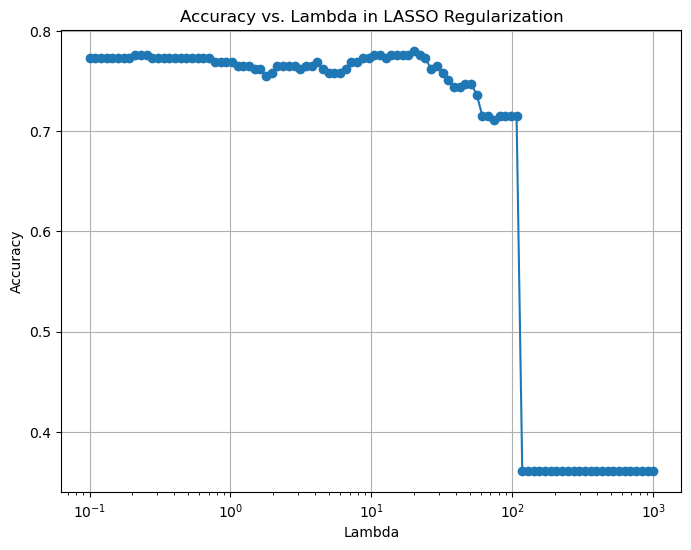

In [14]:
# A plot of how accuracy in the test dataset depends on the regularization strength

C_values = np.logspace(-3, 1, 100)
accuracies = []
for C in C_values:
    lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=C)
    lasso_model.fit(X_train, y_train)
    y_pred = lasso_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

plt.figure(figsize=(8, 6))
plt.plot(1/C_values, accuracies, marker='o')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Lambda in LASSO Regularization')
plt.grid(True)
plt.show()

In [16]:


# Create Lasso Logistic Regression model (L1 regularization)
lasso_logit = LogisticRegression(penalty='l1', solver='liblinear')  # liblinear solver is needed for L1

# Fit the model
lasso_logit.fit(X_train, y_train)

# Predict on the test set
y_pred = lasso_logit.predict(X_test)

# Evaluate Accuracy, Precision, and Recall
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Lasso Logistic Regression:")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")

# Check which features were kept and which were dropped
coefficients = lasso_logit.coef_[0]
features_stayed = np.where(coefficients != 0)[0]
features_dropped = np.where(coefficients == 0)[0]

print(f"Features that stayed: {features_stayed}")
print(f"Features that were dropped: {features_dropped}")


Lasso Logistic Regression:
Accuracy: 0.7689530685920578
Precision: 0.7839195979899497
Recall: 0.8813559322033898
Features that stayed: [ 0  3  4  5  7  8 10 11 12 14 15 17 18 19 21 22 23 26 27 28 29 32]
Features that were dropped: [ 1  2  6  9 13 16 20 24 25 30 31]


In [17]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Create Ridge Regression model (L2 regularization)
ridge_reg = Ridge(alpha=1.0)  # You can adjust the regularization strength (alpha)

# Fit the model
ridge_reg.fit(X_train, y_train)

# Predict on the test set
y_pred_ridge = ridge_reg.predict(X_test)

# Evaluate Mean Squared Error or other regression metrics
mse = mean_squared_error(y_test, y_pred_ridge)

print("Ridge Regression:")
print(f"Mean Squared Error: {mse}")


Ridge Regression:
Mean Squared Error: 0.171654668711962


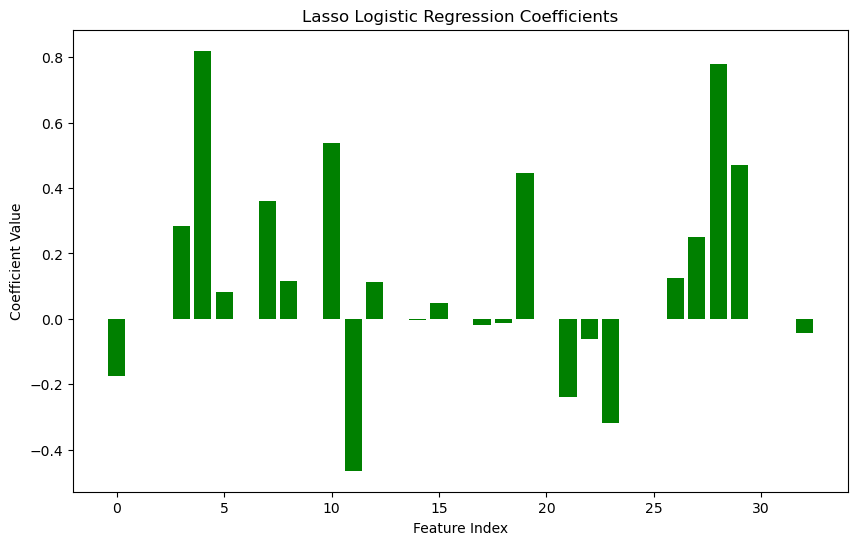

In [18]:
# Plot the coefficients
plt.figure(figsize=(10, 6))
plt.bar(range(len(coefficients)), coefficients, color=['red' if coef == 0 else 'green' for coef in coefficients])
plt.title('Lasso Logistic Regression Coefficients')
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.show()

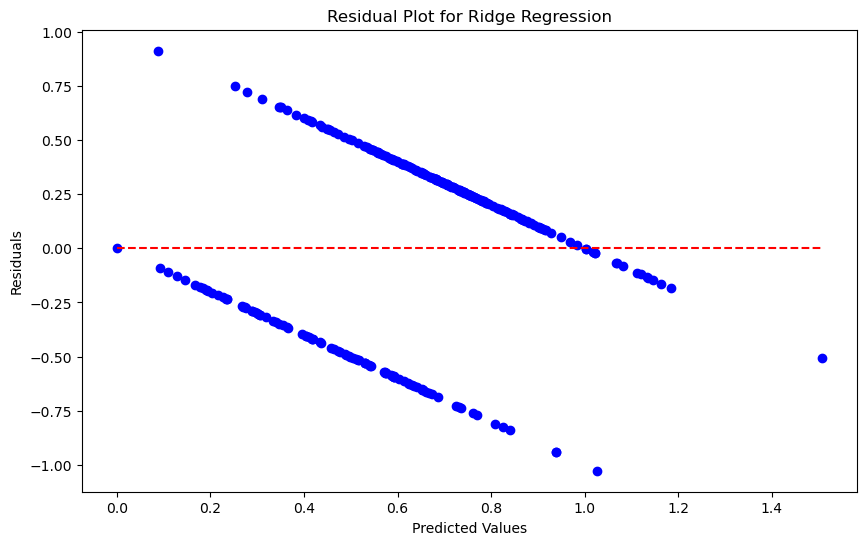

In [19]:
y_pred_ridge = ridge_reg.predict(X_test)

# Compute the residuals (errors)
residuals = y_test - y_pred_ridge

# Plot the residuals
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_ridge, residuals, color='blue')
plt.hlines(y=0, xmin=min(y_pred_ridge), xmax=max(y_pred_ridge), colors='red', linestyles='dashed')
plt.title('Residual Plot for Ridge Regression')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

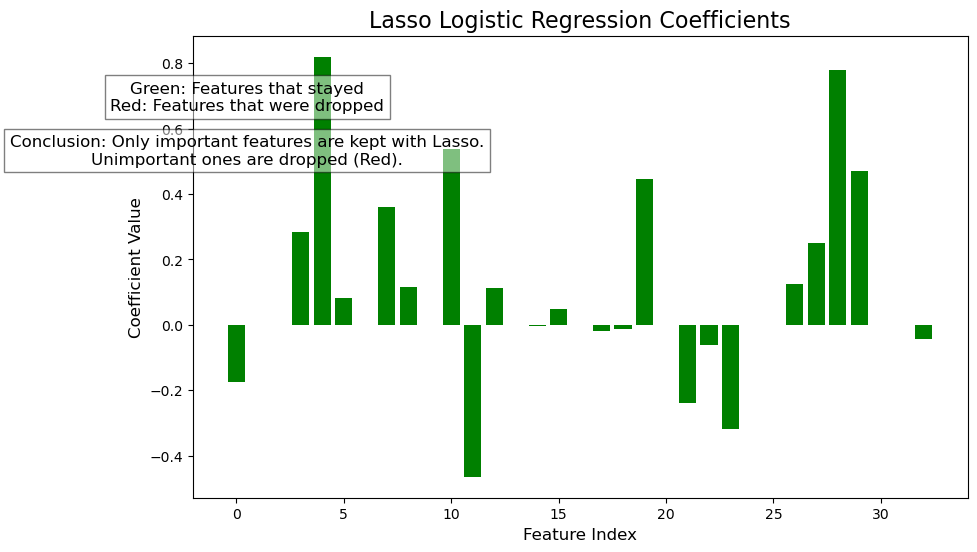

In [20]:
coefficients = lasso_logit.coef_[0]

# Bar color: Green for non-zero (stayed), Red for zero (dropped)
colors = ['red' if coef == 0 else 'green' for coef in coefficients]

# Create the bar plot with labeled explanations
plt.figure(figsize=(10, 6))
plt.bar(range(len(coefficients)), coefficients, color=colors)
plt.title('Lasso Logistic Regression Coefficients', fontsize=16)
plt.xlabel('Feature Index', fontsize=12)
plt.ylabel('Coefficient Value', fontsize=12)

# Add text annotation to the plot to explain the color scheme
plt.text(0.5, max(coefficients) * 0.8, 'Green: Features that stayed\nRed: Features that were dropped', 
         horizontalalignment='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Add conclusion text on the plot
plt.text(0.5, max(coefficients) * 0.6, 'Conclusion: Only important features are kept with Lasso.\nUnimportant ones are dropped (Red).',
         horizontalalignment='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

plt.show()

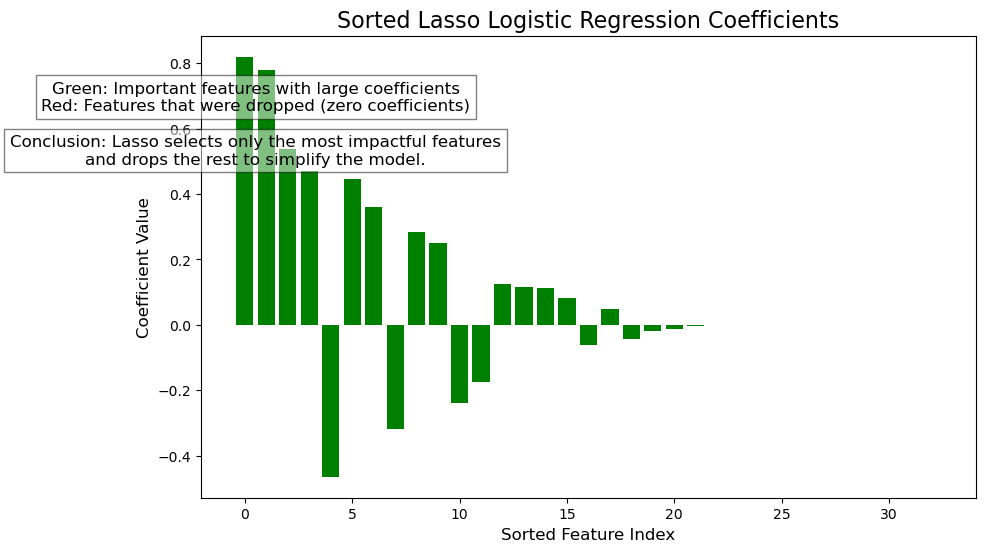

In [21]:
# Sort the coefficients by their absolute values
sorted_indices = np.argsort(np.abs(coefficients))[::-1]

# Plot the sorted coefficients with labeled explanations
plt.figure(figsize=(10, 6))
plt.bar(range(len(coefficients)), coefficients[sorted_indices], color=['green' if coef != 0 else 'red' for coef in coefficients[sorted_indices]])
plt.title('Sorted Lasso Logistic Regression Coefficients', fontsize=16)
plt.xlabel('Sorted Feature Index', fontsize=12)
plt.ylabel('Coefficient Value', fontsize=12)

# Add a simple text explanation
plt.text(0.5, max(coefficients) * 0.8, 'Green: Important features with large coefficients\nRed: Features that were dropped (zero coefficients)', 
         horizontalalignment='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Add conclusion
plt.text(0.5, max(coefficients) * 0.6, 'Conclusion: Lasso selects only the most impactful features\nand drops the rest to simplify the model.',
         horizontalalignment='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

plt.show()
